In [1]:
import sys
sys.path.append('../')

In [2]:
from src.simulation import EconomyRunner
from src.economy import (
    DiscreteStateAgentEconomy,
    FixedAmountTransaction, 
    DiscreteRandomSplit, DiscreteTruncatedRandomSplit,
)
from src.visualization import plot_wealth_distribution
import numpy as np

# High-Liquidity Discrete Thermodynamic Limit

Large $N,M$ and high liquidity $M \gg N$

Using the discrete random split interaction should allow for a smaller amount of transactions to reach equilibrium

In [3]:
num_agents = int(1e4)
total_wealth = num_agents * int(1e2)
num_transactions = int(5e6)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=DiscreteRandomSplit()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

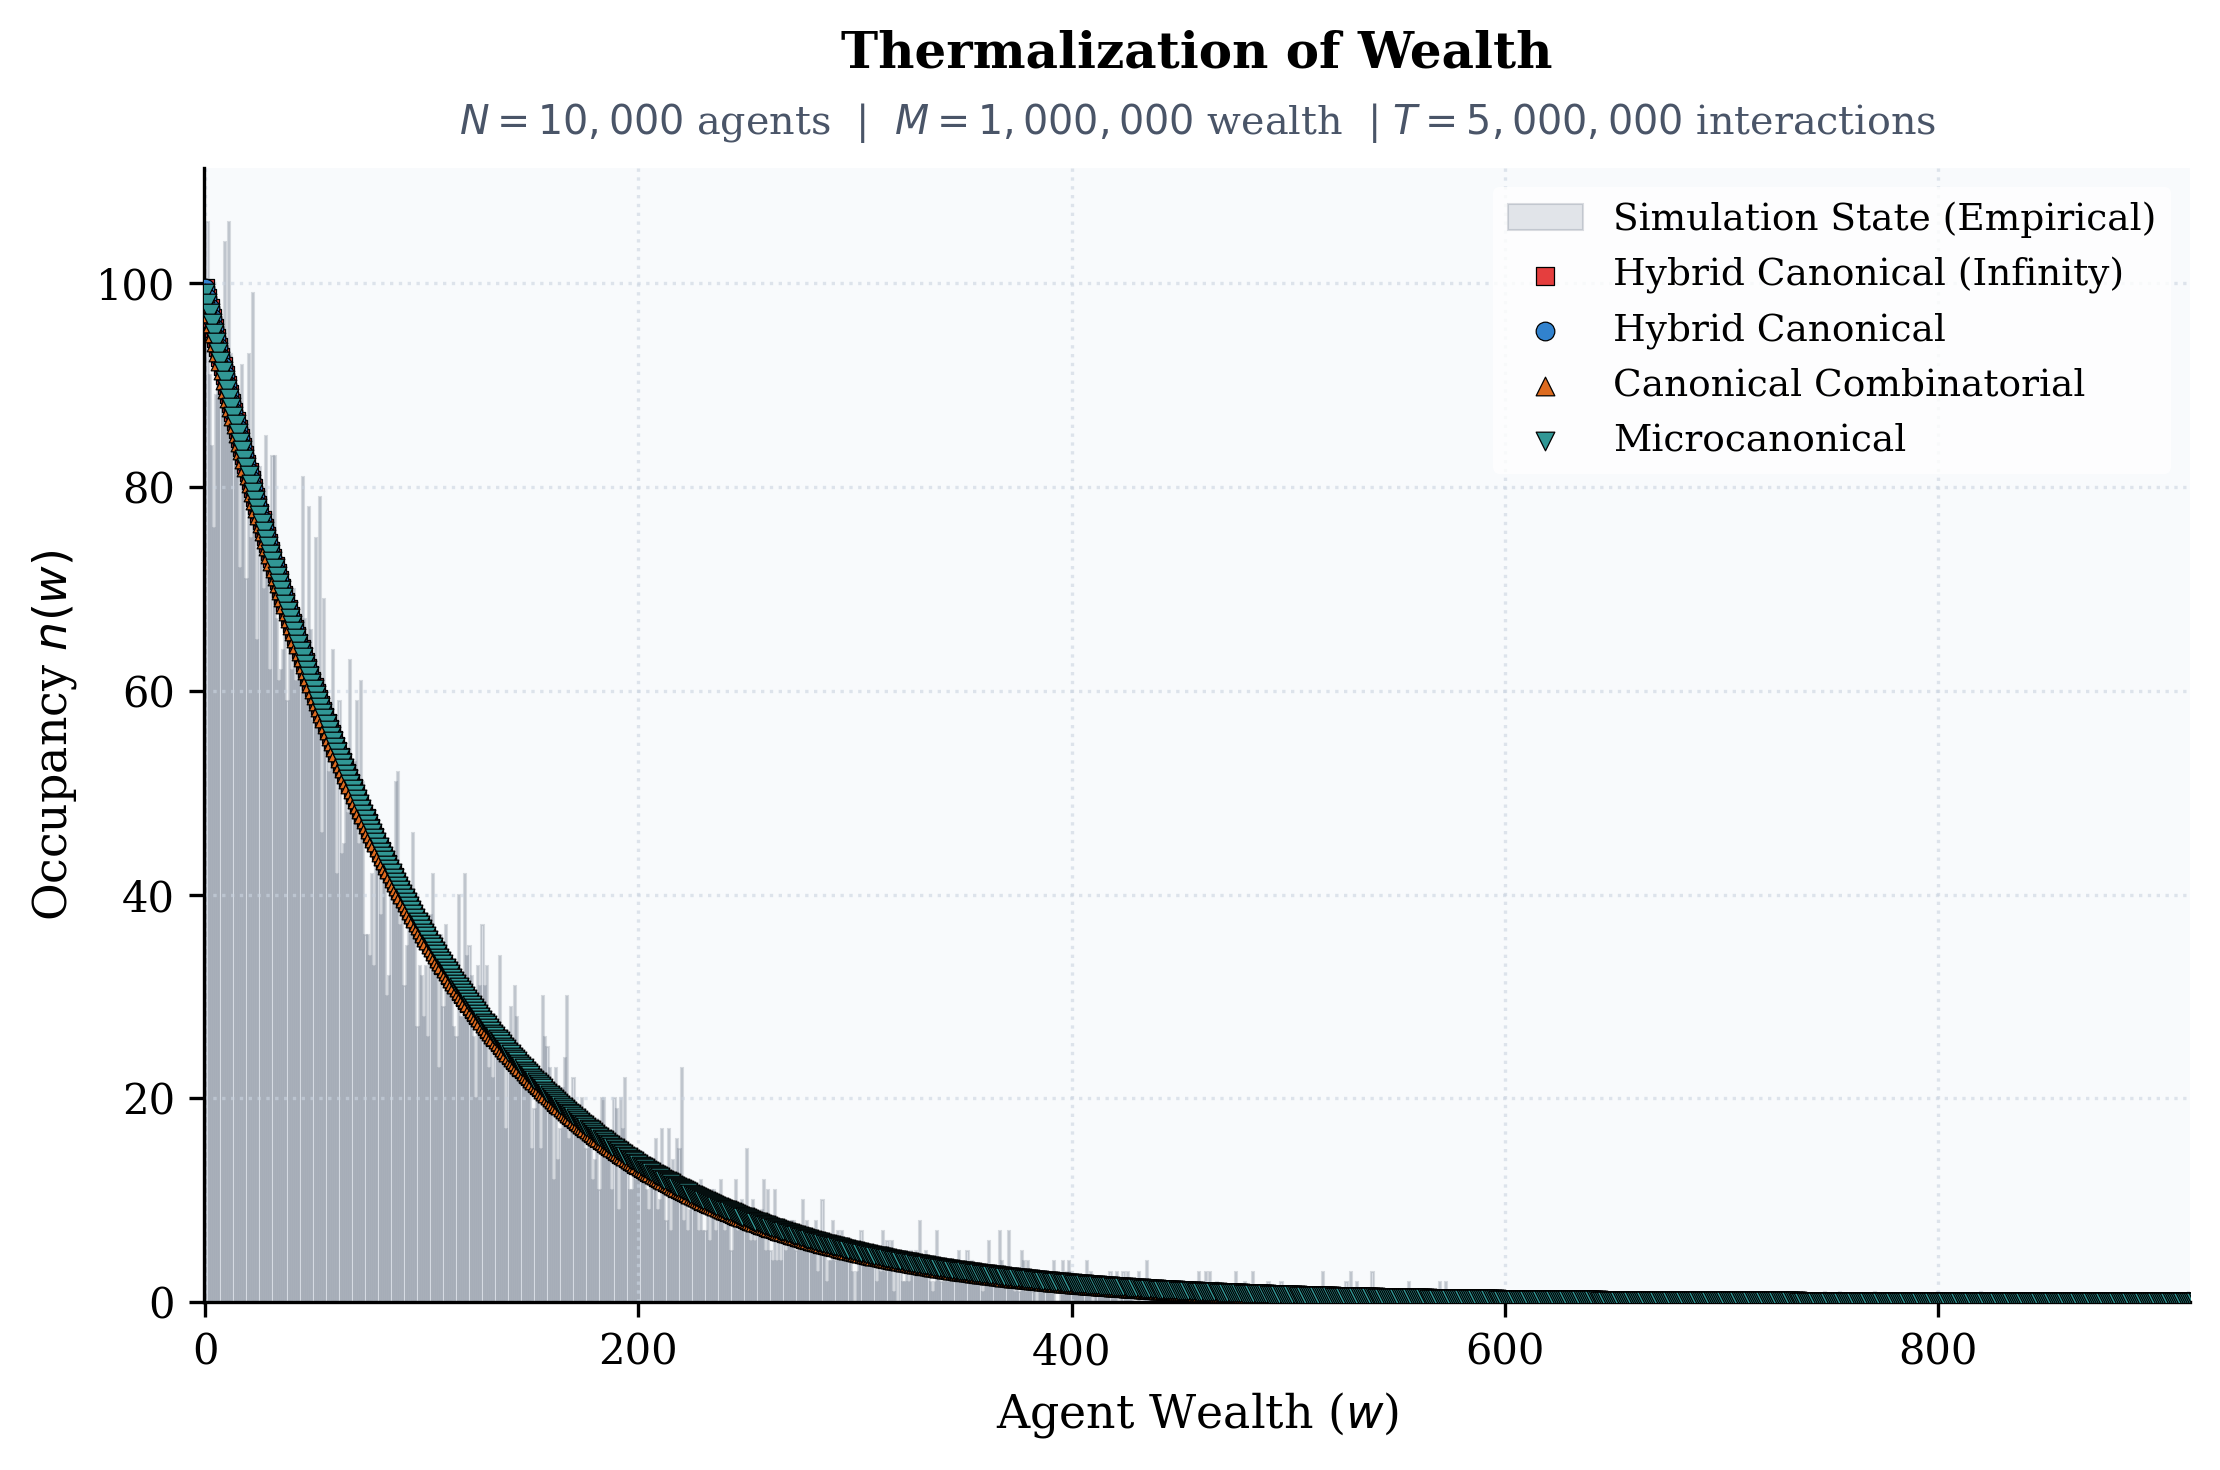

In [4]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=False, plot_title='Thermalization of Wealth'
)

As expected, all theoretical predictions look virtually the same in this regime.

There's non-negligible variability introduced by the discrete random splitting when the average wealth per agent is relatively large (i.e. in this case of 100 units per agent). The explanation of this effect is deferred at the moment, but it's hypothesized to be connected to a high number of accesible wealth levels for an agent. In relative terms, it will be connected to the ratio of variance in the probability distribution for an individual agent to the expected wealth, which will possibly be an inverse power function of the number of agents.

#

### Fixed Transaction Unit Interaction Strategy
Using the fixed amount transaction interaction should smooth the empirical distribution, but will require significant more transactions

In [5]:
num_agents = int(1e4)
total_wealth = num_agents * int(1e2)
num_transactions = int(100e6)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=FixedAmountTransaction()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

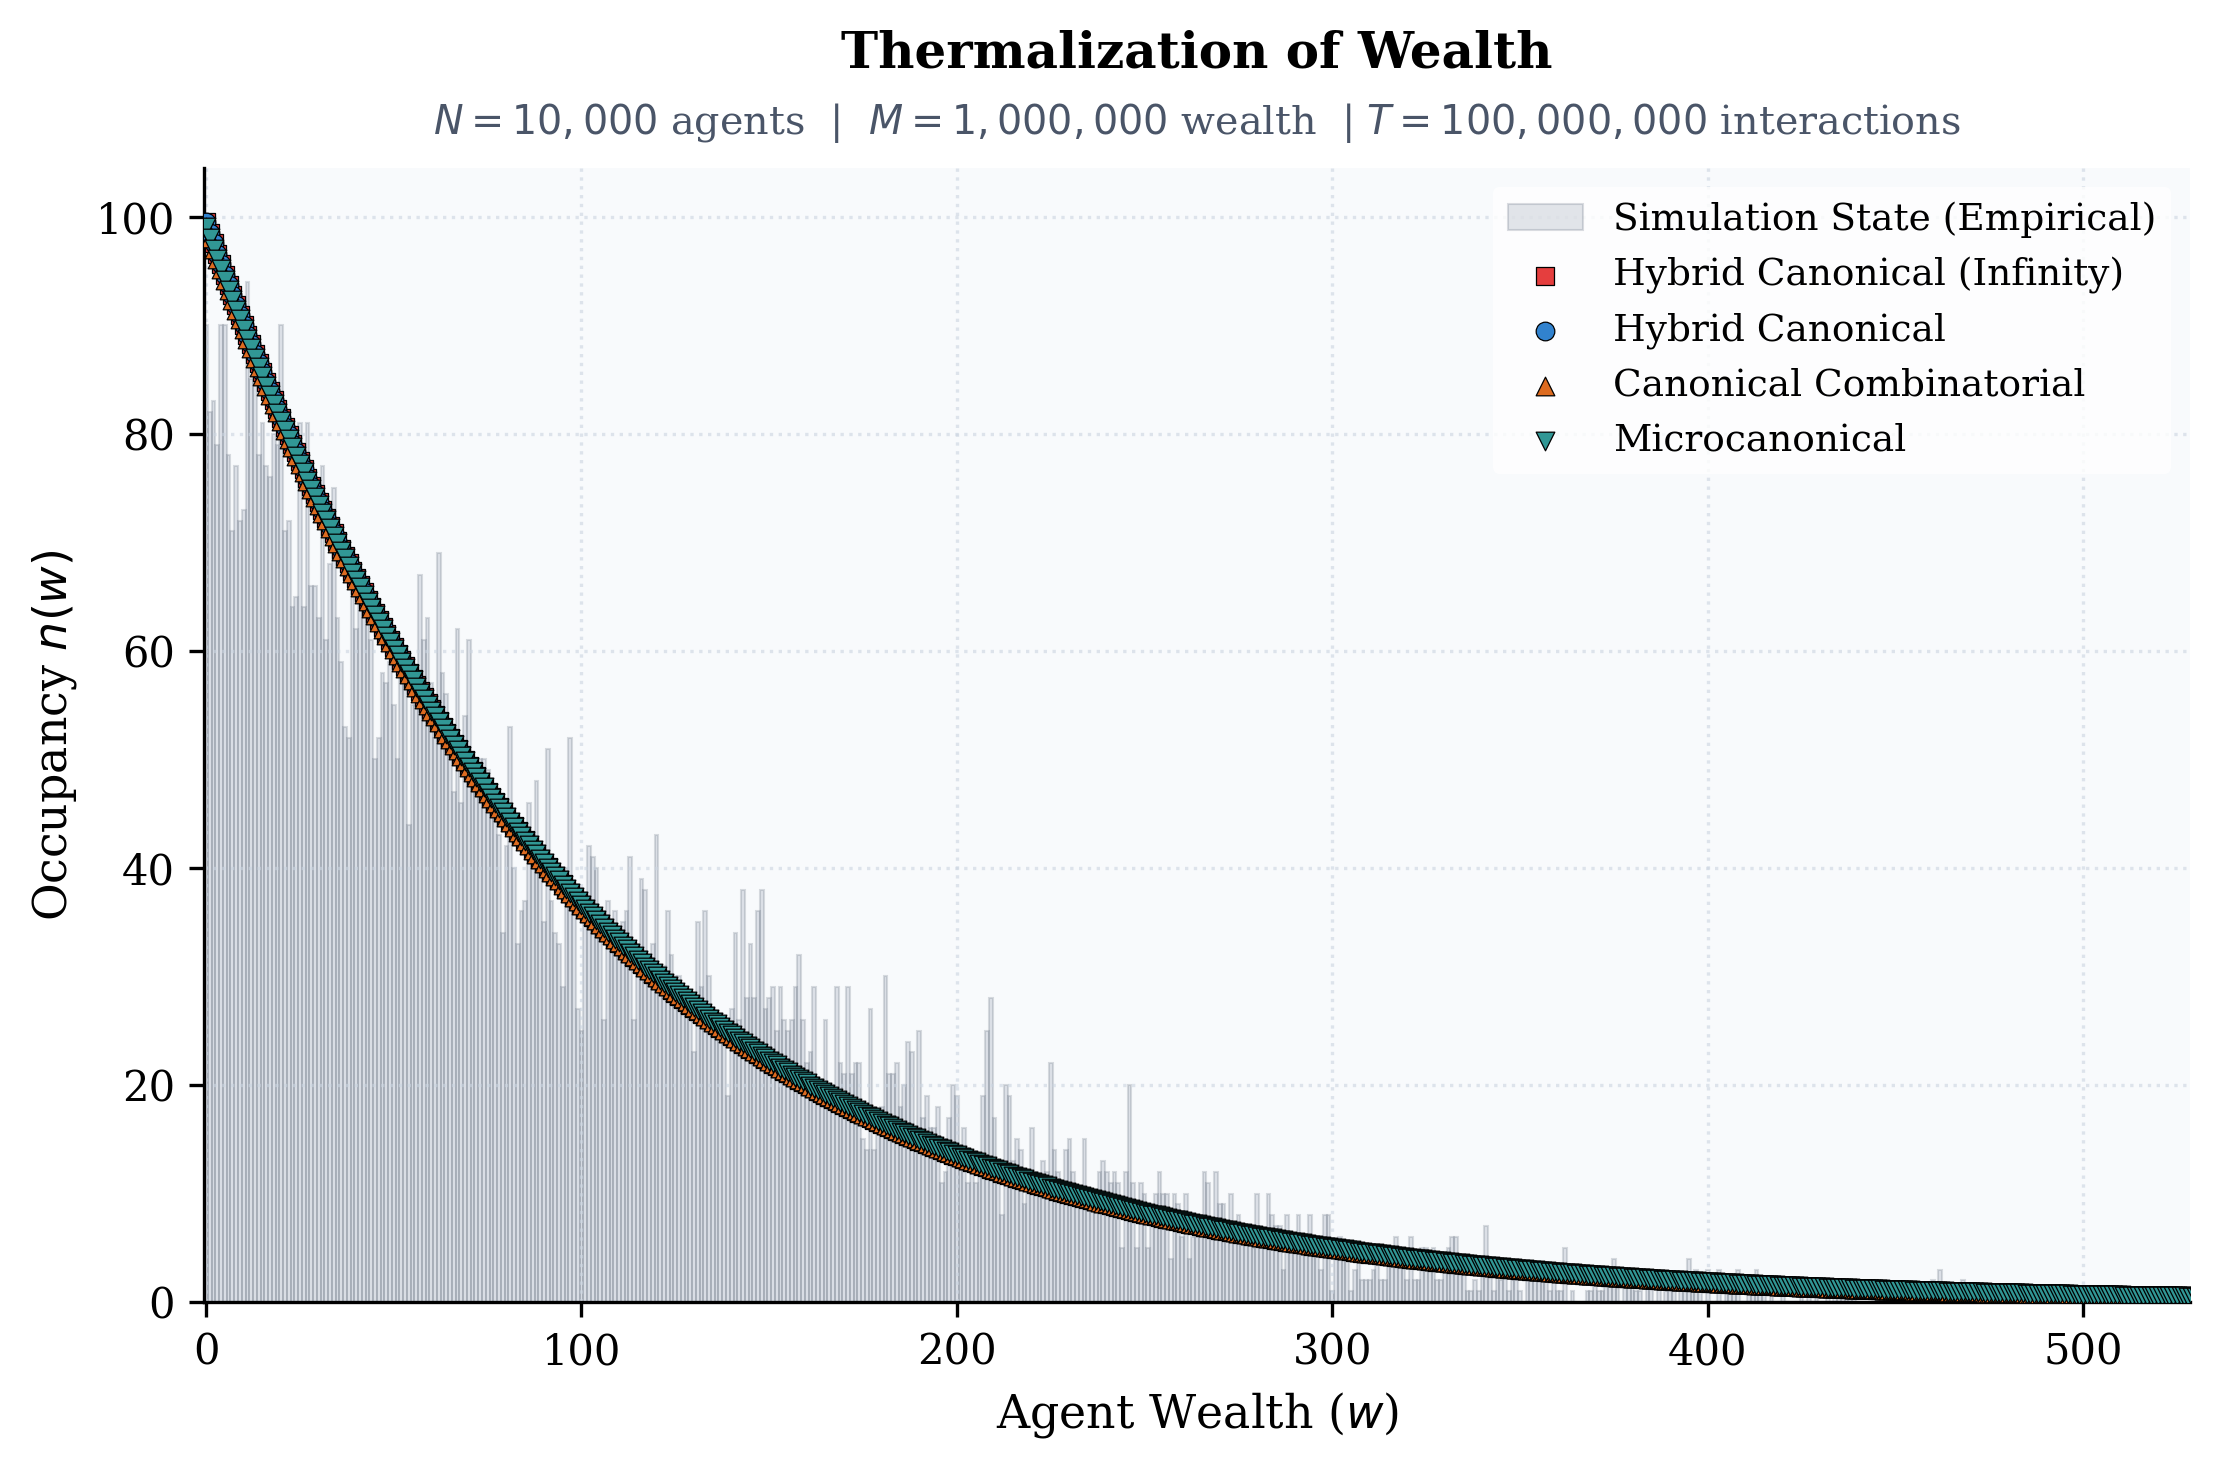

In [6]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=False, plot_title='Thermalization of Wealth'
)

In [7]:
num_agents = int(4e4)
total_wealth = num_agents * int(1e1)
num_transactions = int(25e6)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=FixedAmountTransaction()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

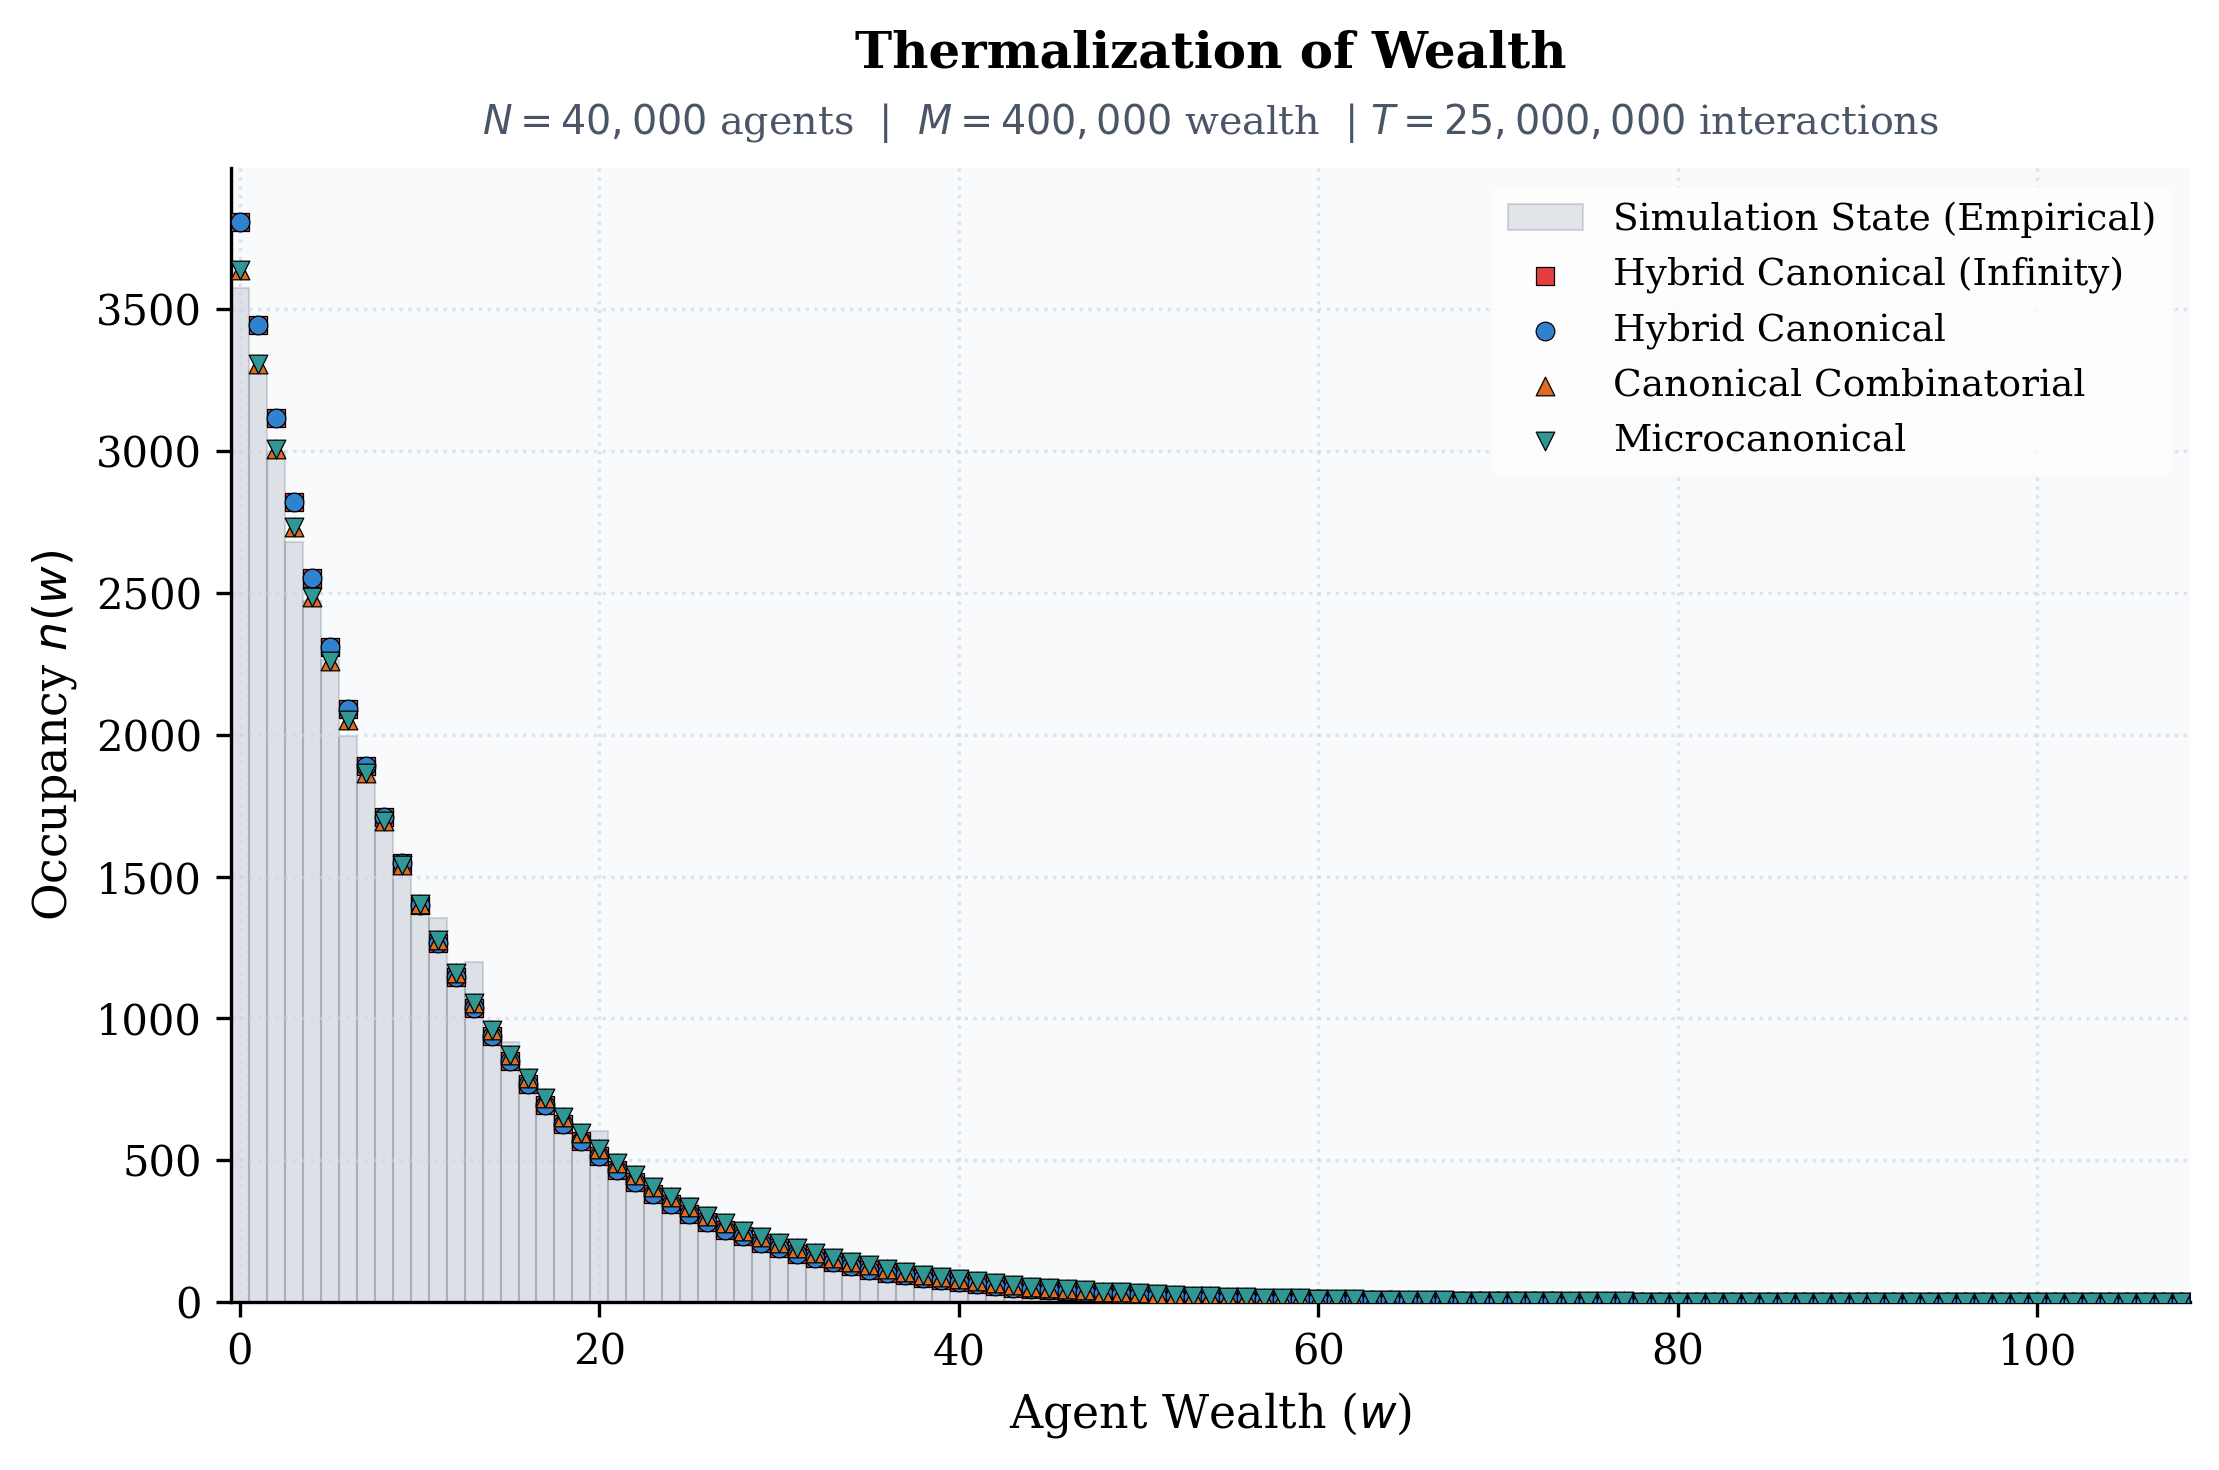

In [8]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=False, plot_title='Thermalization of Wealth'
)

# Large Non-Liquid Discrete System

Large $N,M$ but no high liquidity $M \approx N$

Using the discrete random split interaction should allow for a smaller amount of transactions to reach equilibrium. This time, the variability should decrease as the average pot size per transaction is close to unity.

In [9]:
num_agents = int(1e4)
total_wealth = num_agents
num_transactions = int(5e6)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=DiscreteRandomSplit()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

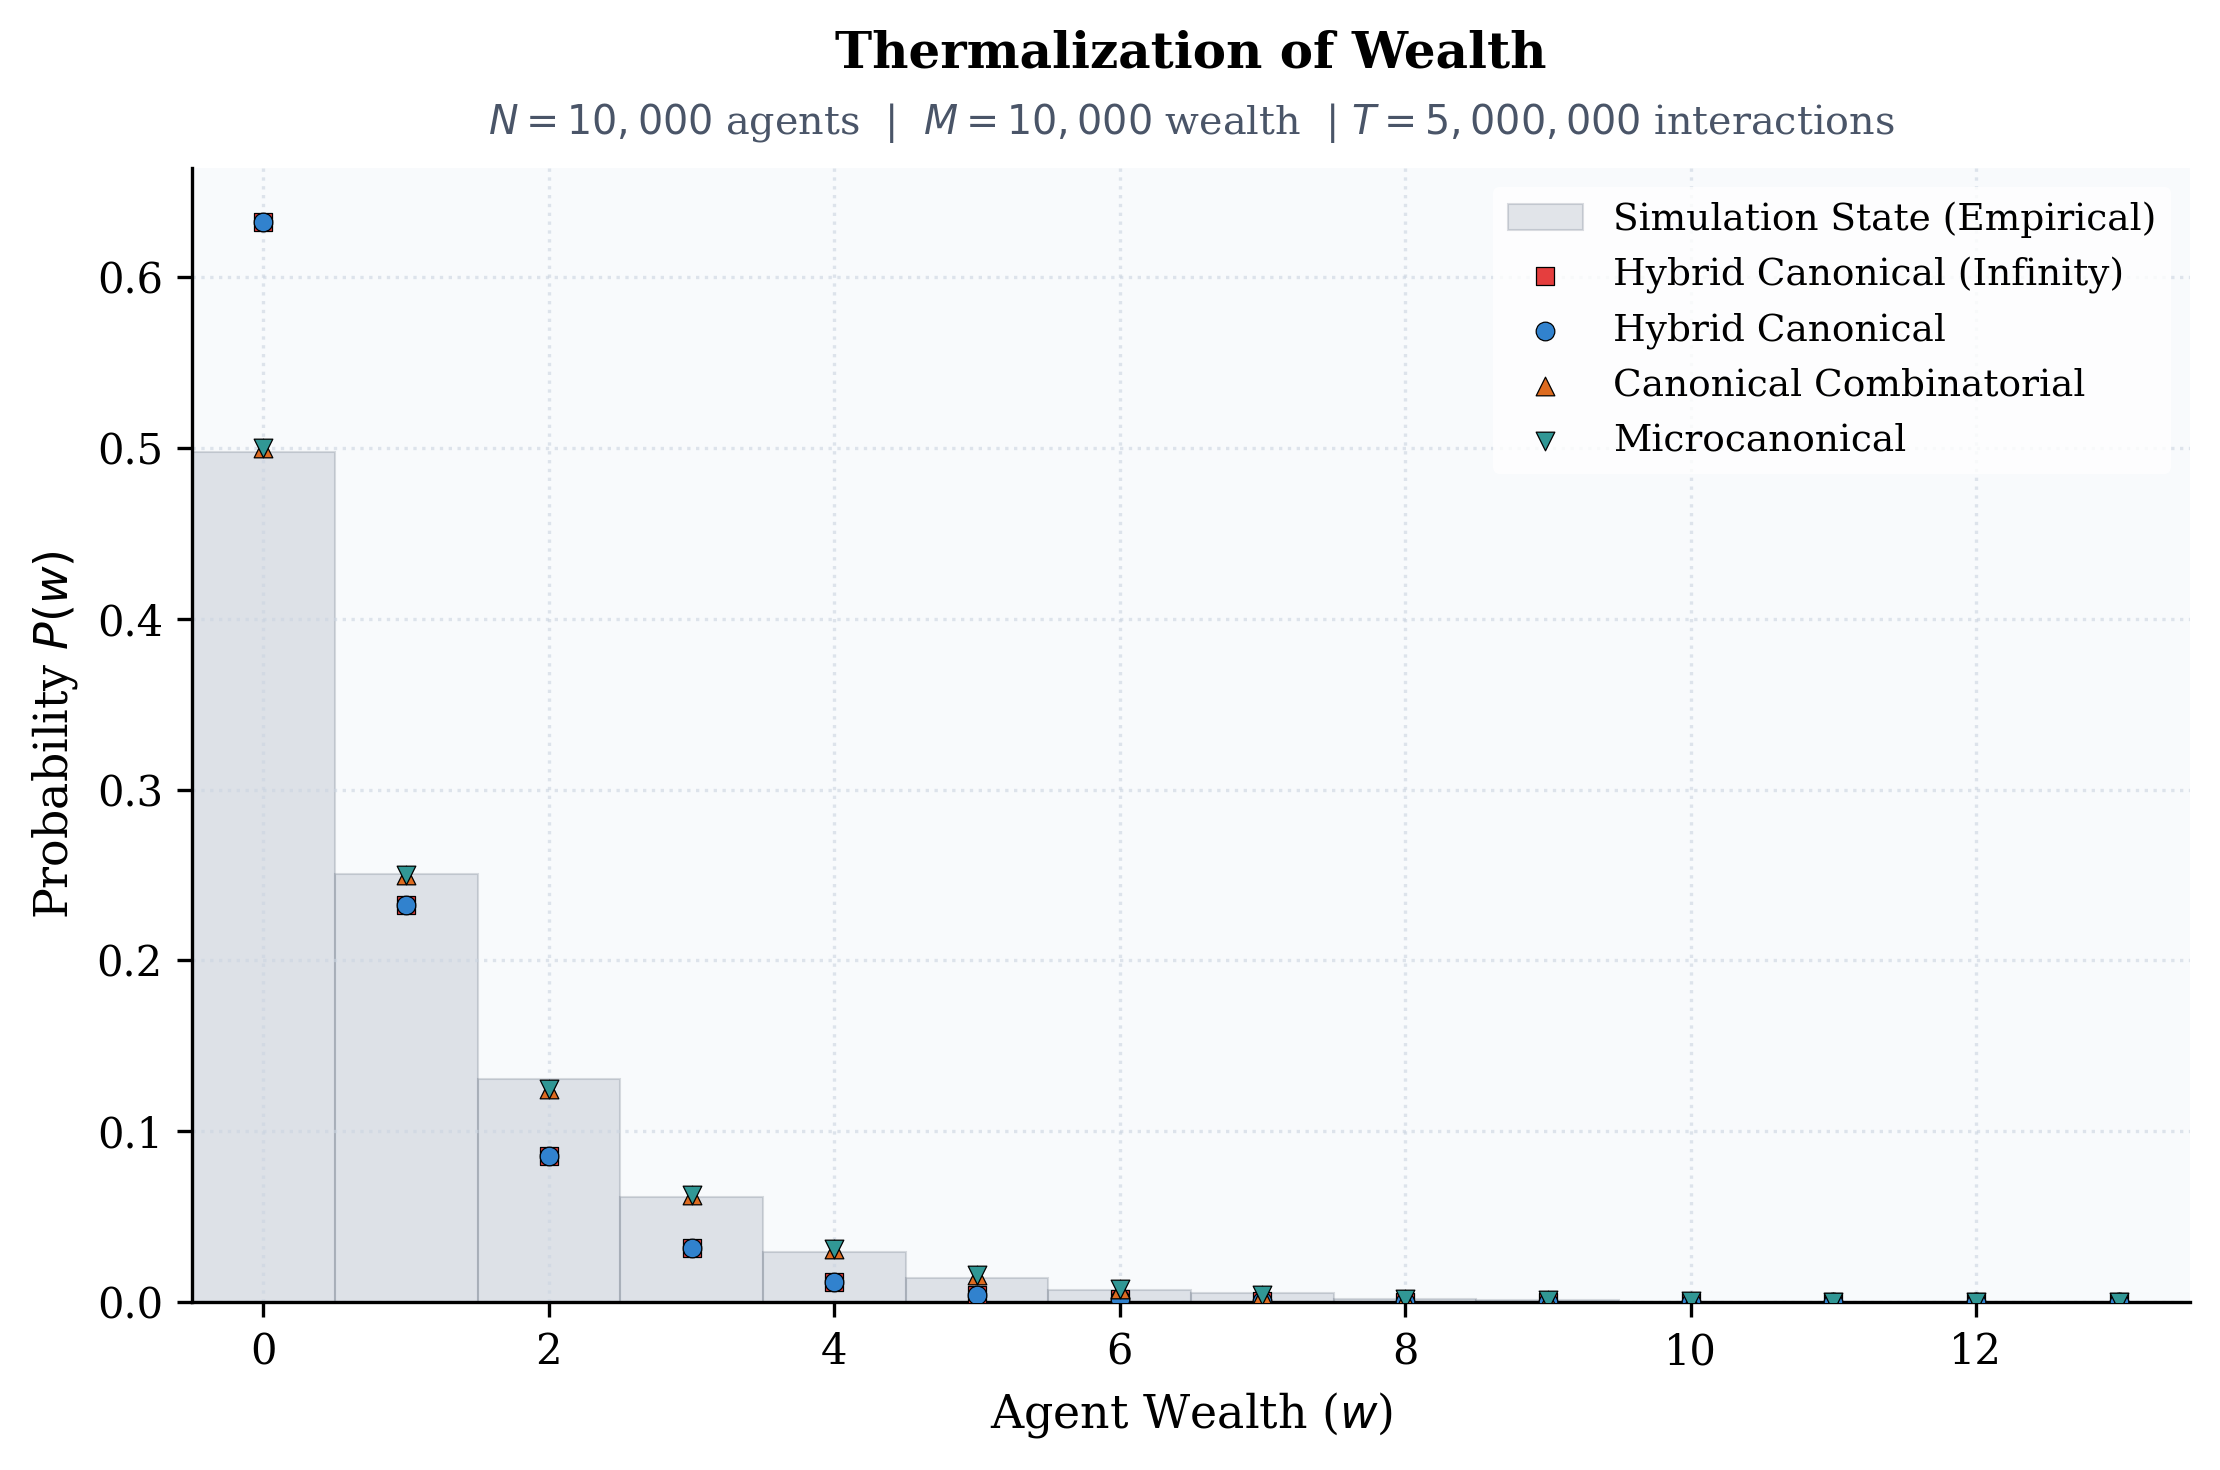

In [10]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=True, plot_title='Thermalization of Wealth'
)

As expected from the convergence analysis, the canonical combinatorial and microcanonical predictions are virtually identical and predict the stationary state better than the hybrid canonical. At this scale, the simulation matches the predictions of each approach for $M \approx N$ and asymptotic $M$ with the canonical combinatorial and microcanonical predicting a base ($w=0$) probability of $0.5$ while the hybrid combinatorial predicts a probability of $\approx 0.63$.

# Small Discrete Systems

Small $N,M$ and $N\approx M$

In [15]:
num_agents = 20
total_wealth = num_agents
num_transactions = int(5e4)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=FixedAmountTransaction()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

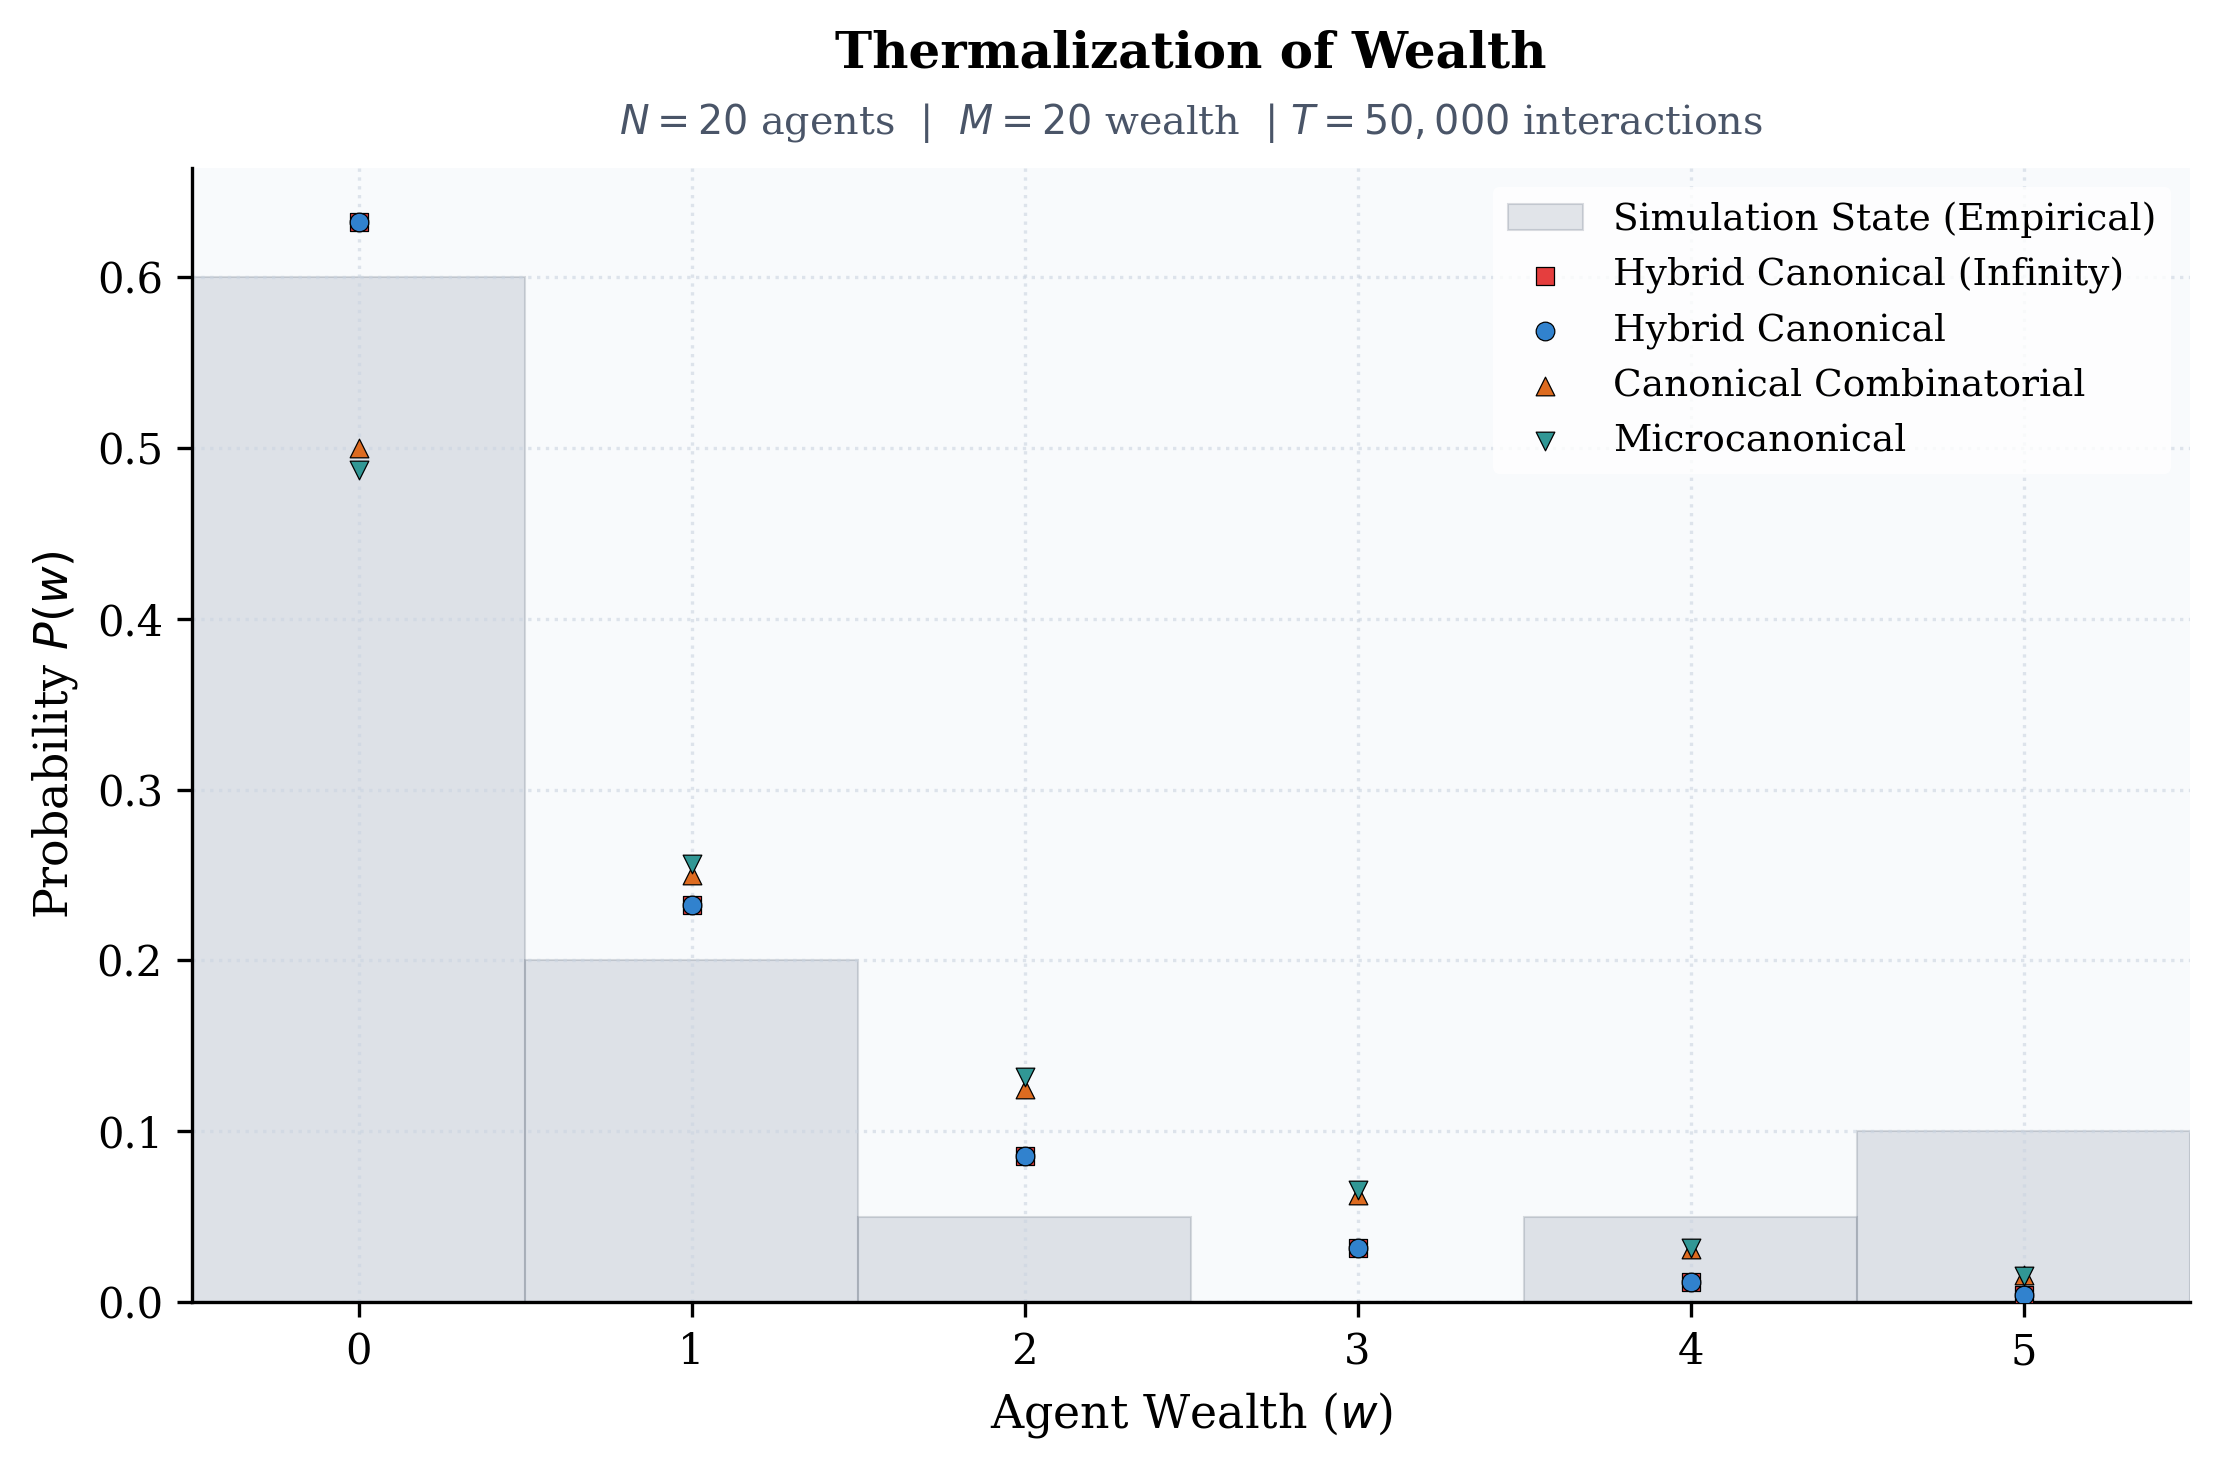

In [16]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=True, plot_title='Thermalization of Wealth'
)

Heavy variability observed across simulation runs. Convergence to predictions expected to happen at average occupancies across simulations.

### Averaging Occupancies

In [17]:
num_agents = 20
total_wealth = num_agents
num_transactions = int(5e4)

bins = np.arange(0, total_wealth + 2) - 0.5
centers = np.arange(0, total_wealth + 1)
replicas_occupancies = []
replicas = 30

for i in range(replicas):
    runner = EconomyRunner(
            num_agents=num_agents,
            total_wealth=total_wealth,
            num_transactions=num_transactions,
            economy_cls=DiscreteStateAgentEconomy, 
            strategy=FixedAmountTransaction()
        )

    final_wealths, balance_history, history_time, theory_curves = runner.run()
    replicas_occupancies.append(np.histogram(final_wealths, bins=bins)[0])

In [18]:
avg_wealths = np.array([np.mean(replica_occupancies) for replica_occupancies in np.column_stack(replicas_occupancies)])

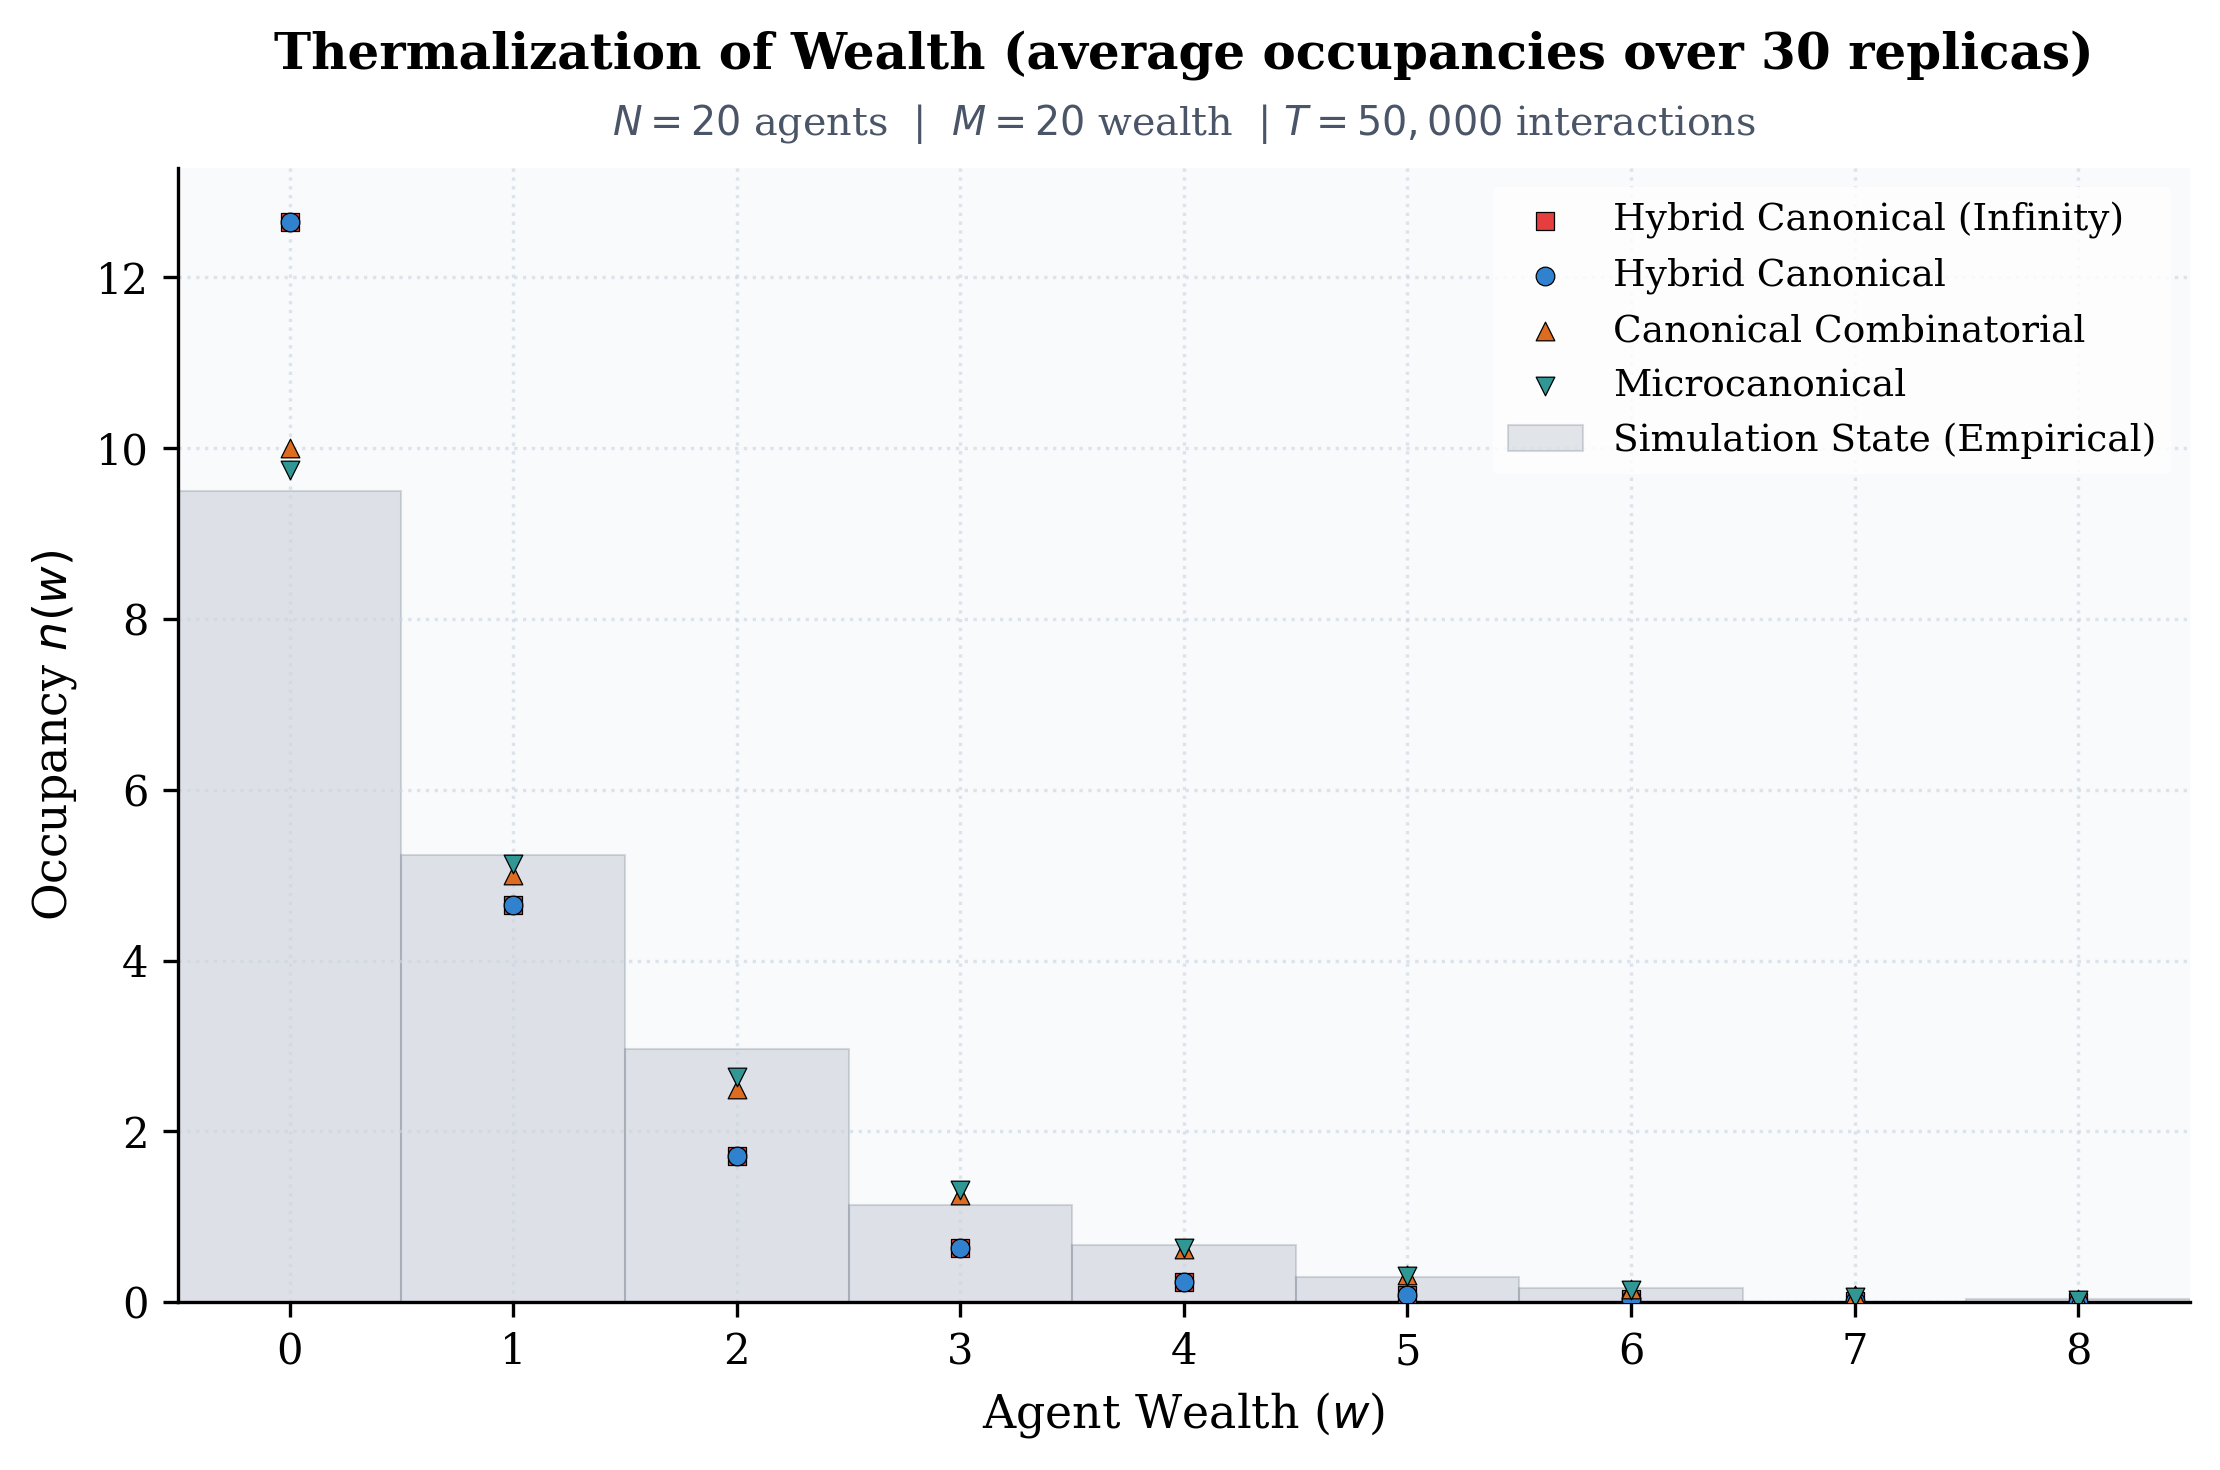

In [19]:
fig = plot_wealth_distribution(
    final_wealths=None,
    occupancies=avg_wealths, centers=centers,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=False, plot_title=f'Thermalization of Wealth (average occupancies over {replicas} replicas)'
)

The canonical combinatorial and microcanonical predicting a base ($m=0$) probability of $0.5$ (in this case implying occupancy of 10/20 agents) is relatively accurate, while the hybrid combinatorial is consistently off by predicting a probability of $\approx 0.63$ for the base wealth.

# Intermediate Economy Size

In [20]:
num_agents = 400
total_wealth = num_agents * 5
num_transactions = int(2e6)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=FixedAmountTransaction()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

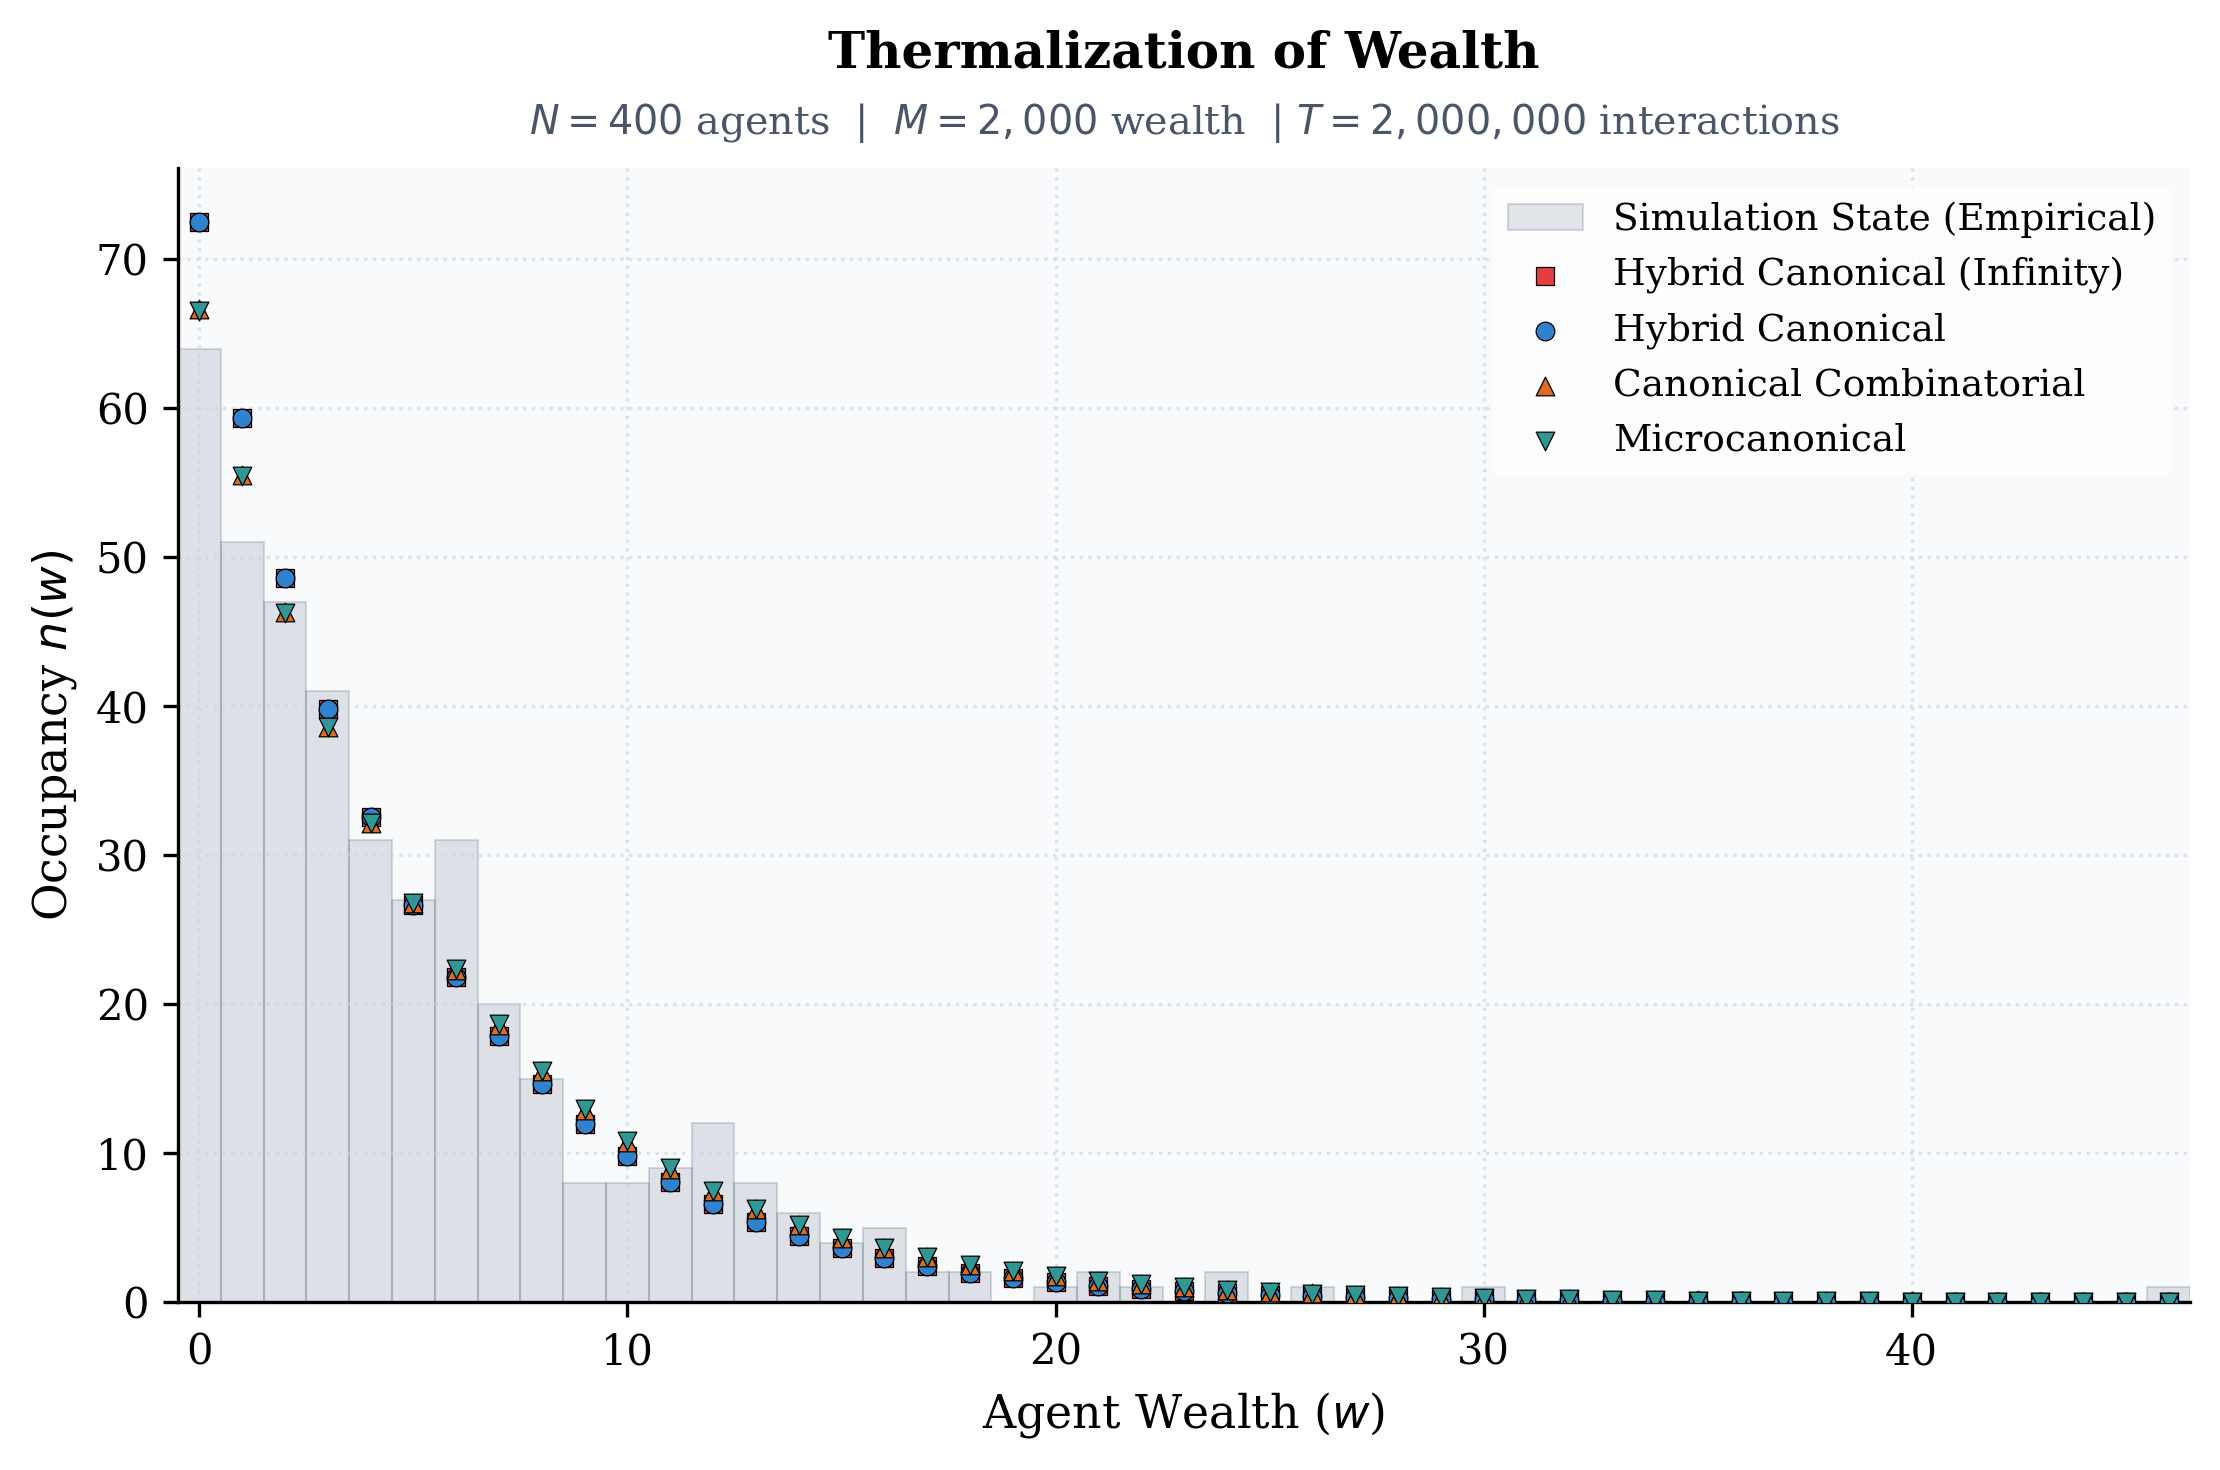

In [21]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=False, plot_title='Thermalization of Wealth'
)

In [22]:
num_agents = 2000
total_wealth = 2000
num_transactions = int(1e6)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=DiscreteRandomSplit()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

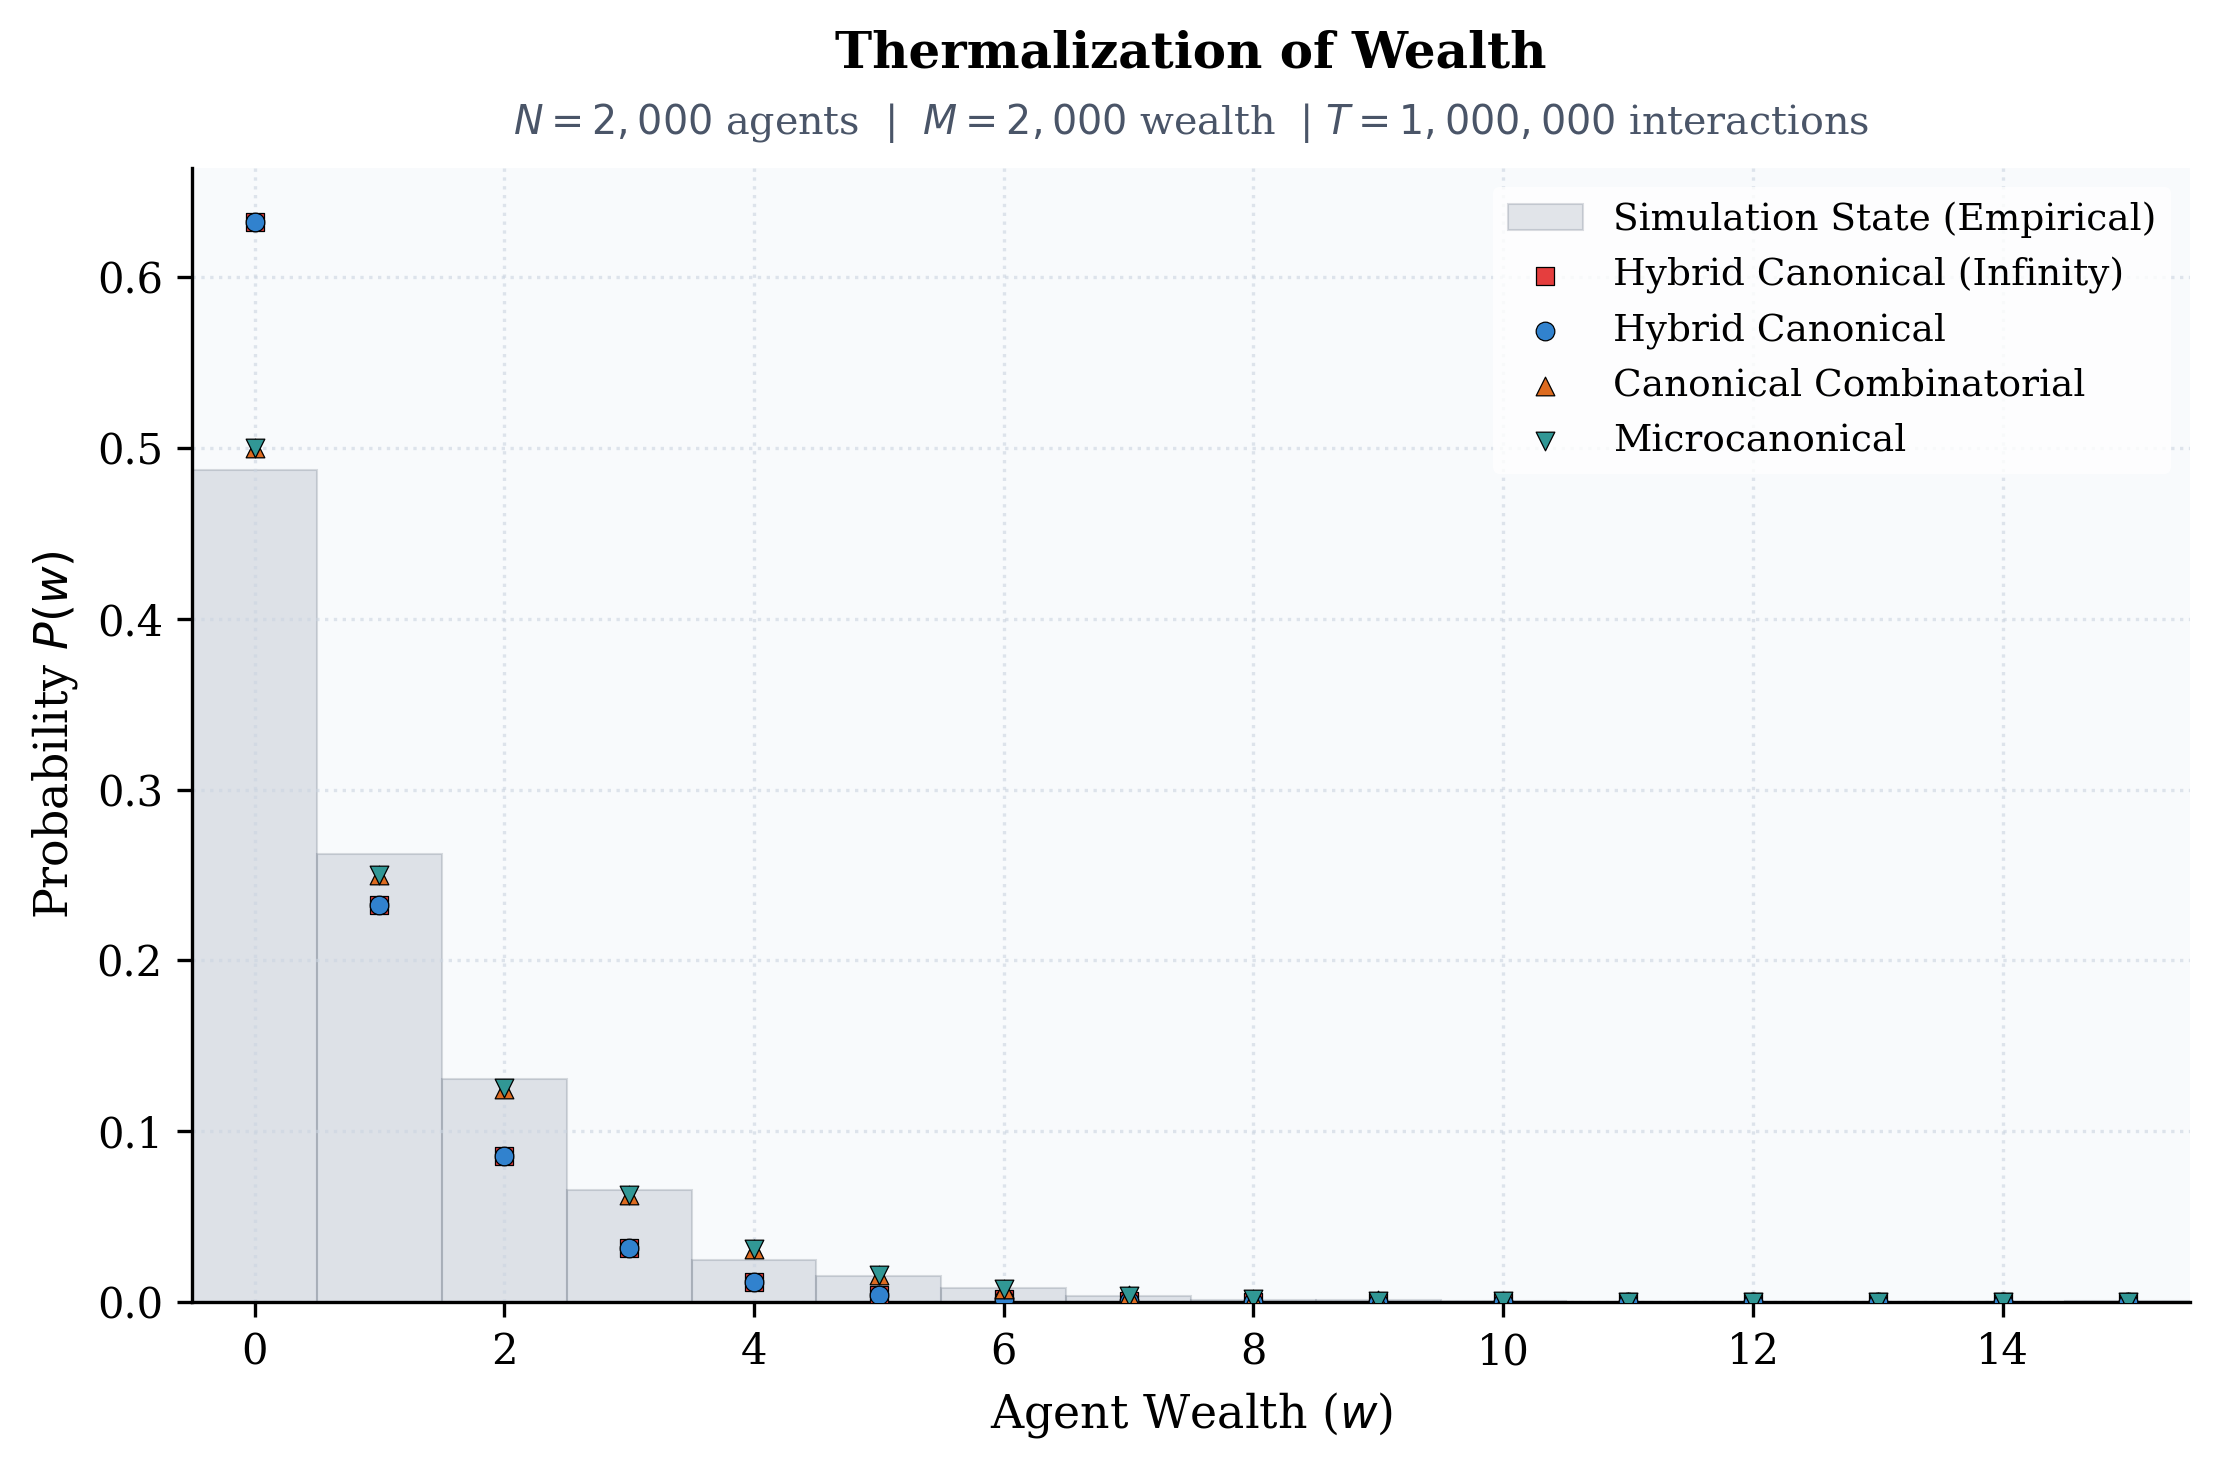

In [23]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=True, plot_title='Thermalization of Wealth'
)

In [24]:
num_agents = 2000
total_wealth = num_agents * 10
num_transactions = int(5e6)

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=DiscreteRandomSplit()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

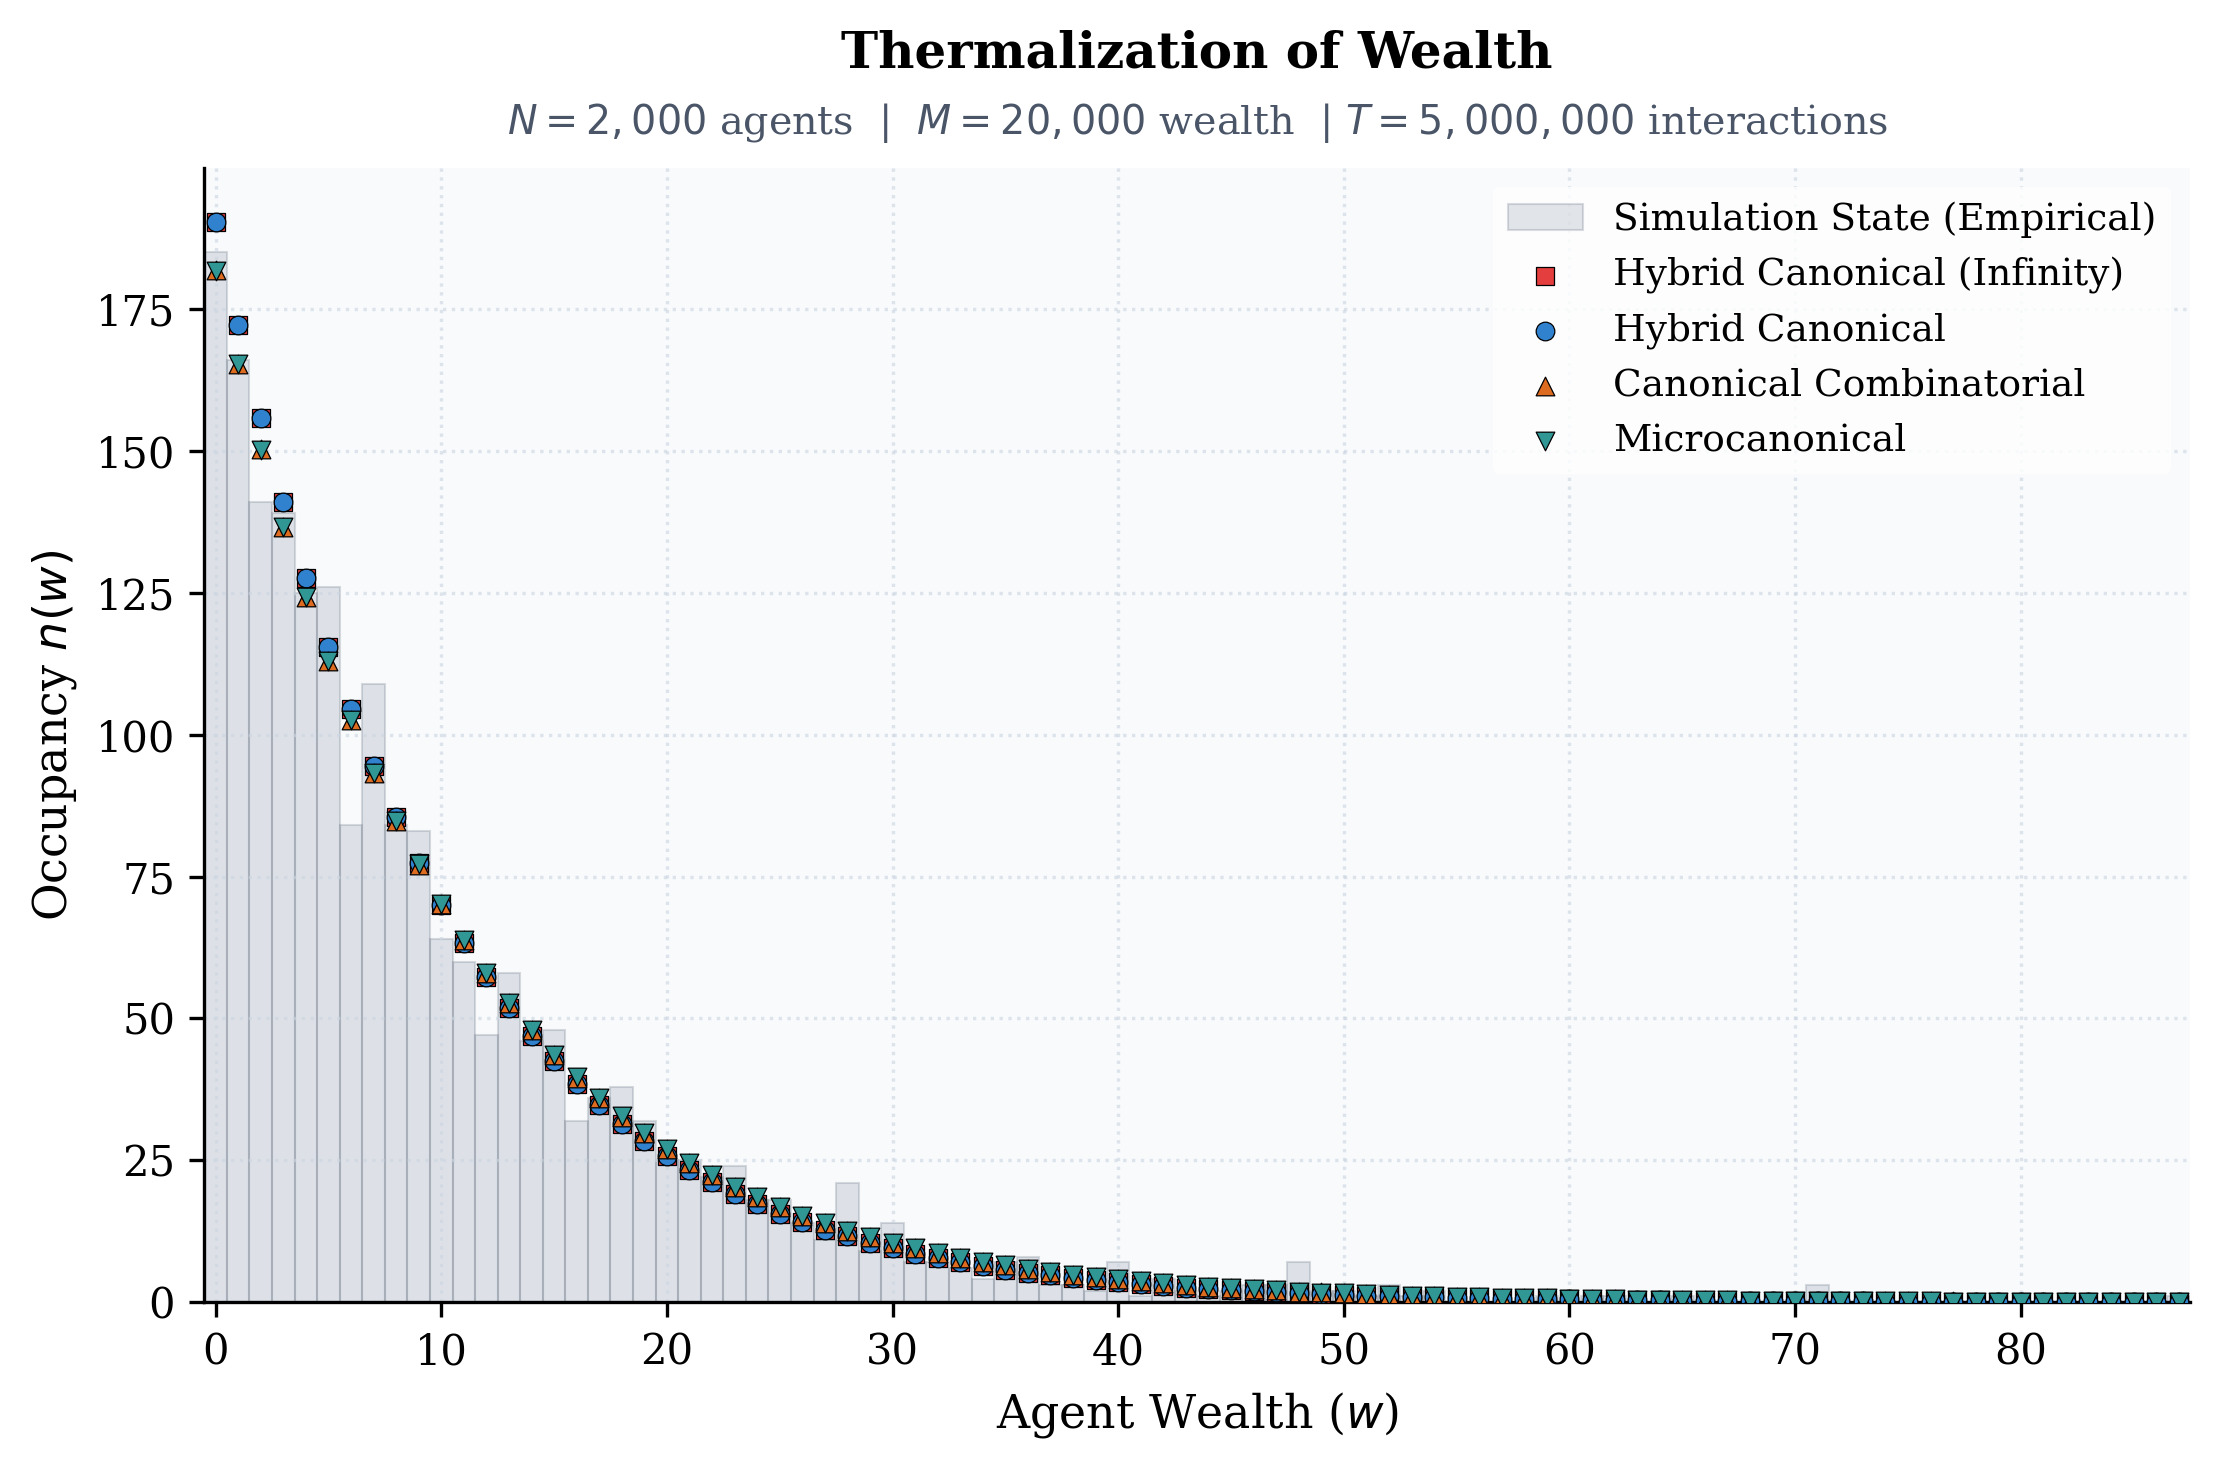

In [25]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=False, plot_title='Thermalization of Wealth'
)

# Interaction Strategies

We have observed the behavior of the dynamic splitting and fixed trade unit. We know study the implementation of a bias through truncated splitting.

#

### Truncated random split

In later phases this interaction strategy will be shown to introduce a bias similar to the savings propensity model.

In [26]:
num_agents = 2000
total_wealth = num_agents * 5
num_transactions = total_wealth * 10

runner = EconomyRunner(
        num_agents=num_agents,
        total_wealth=total_wealth,
        num_transactions=num_transactions,
        economy_cls=DiscreteStateAgentEconomy, 
        strategy=DiscreteTruncatedRandomSplit()
    )

final_wealths, balance_history, history_time, theory_curves = runner.run()

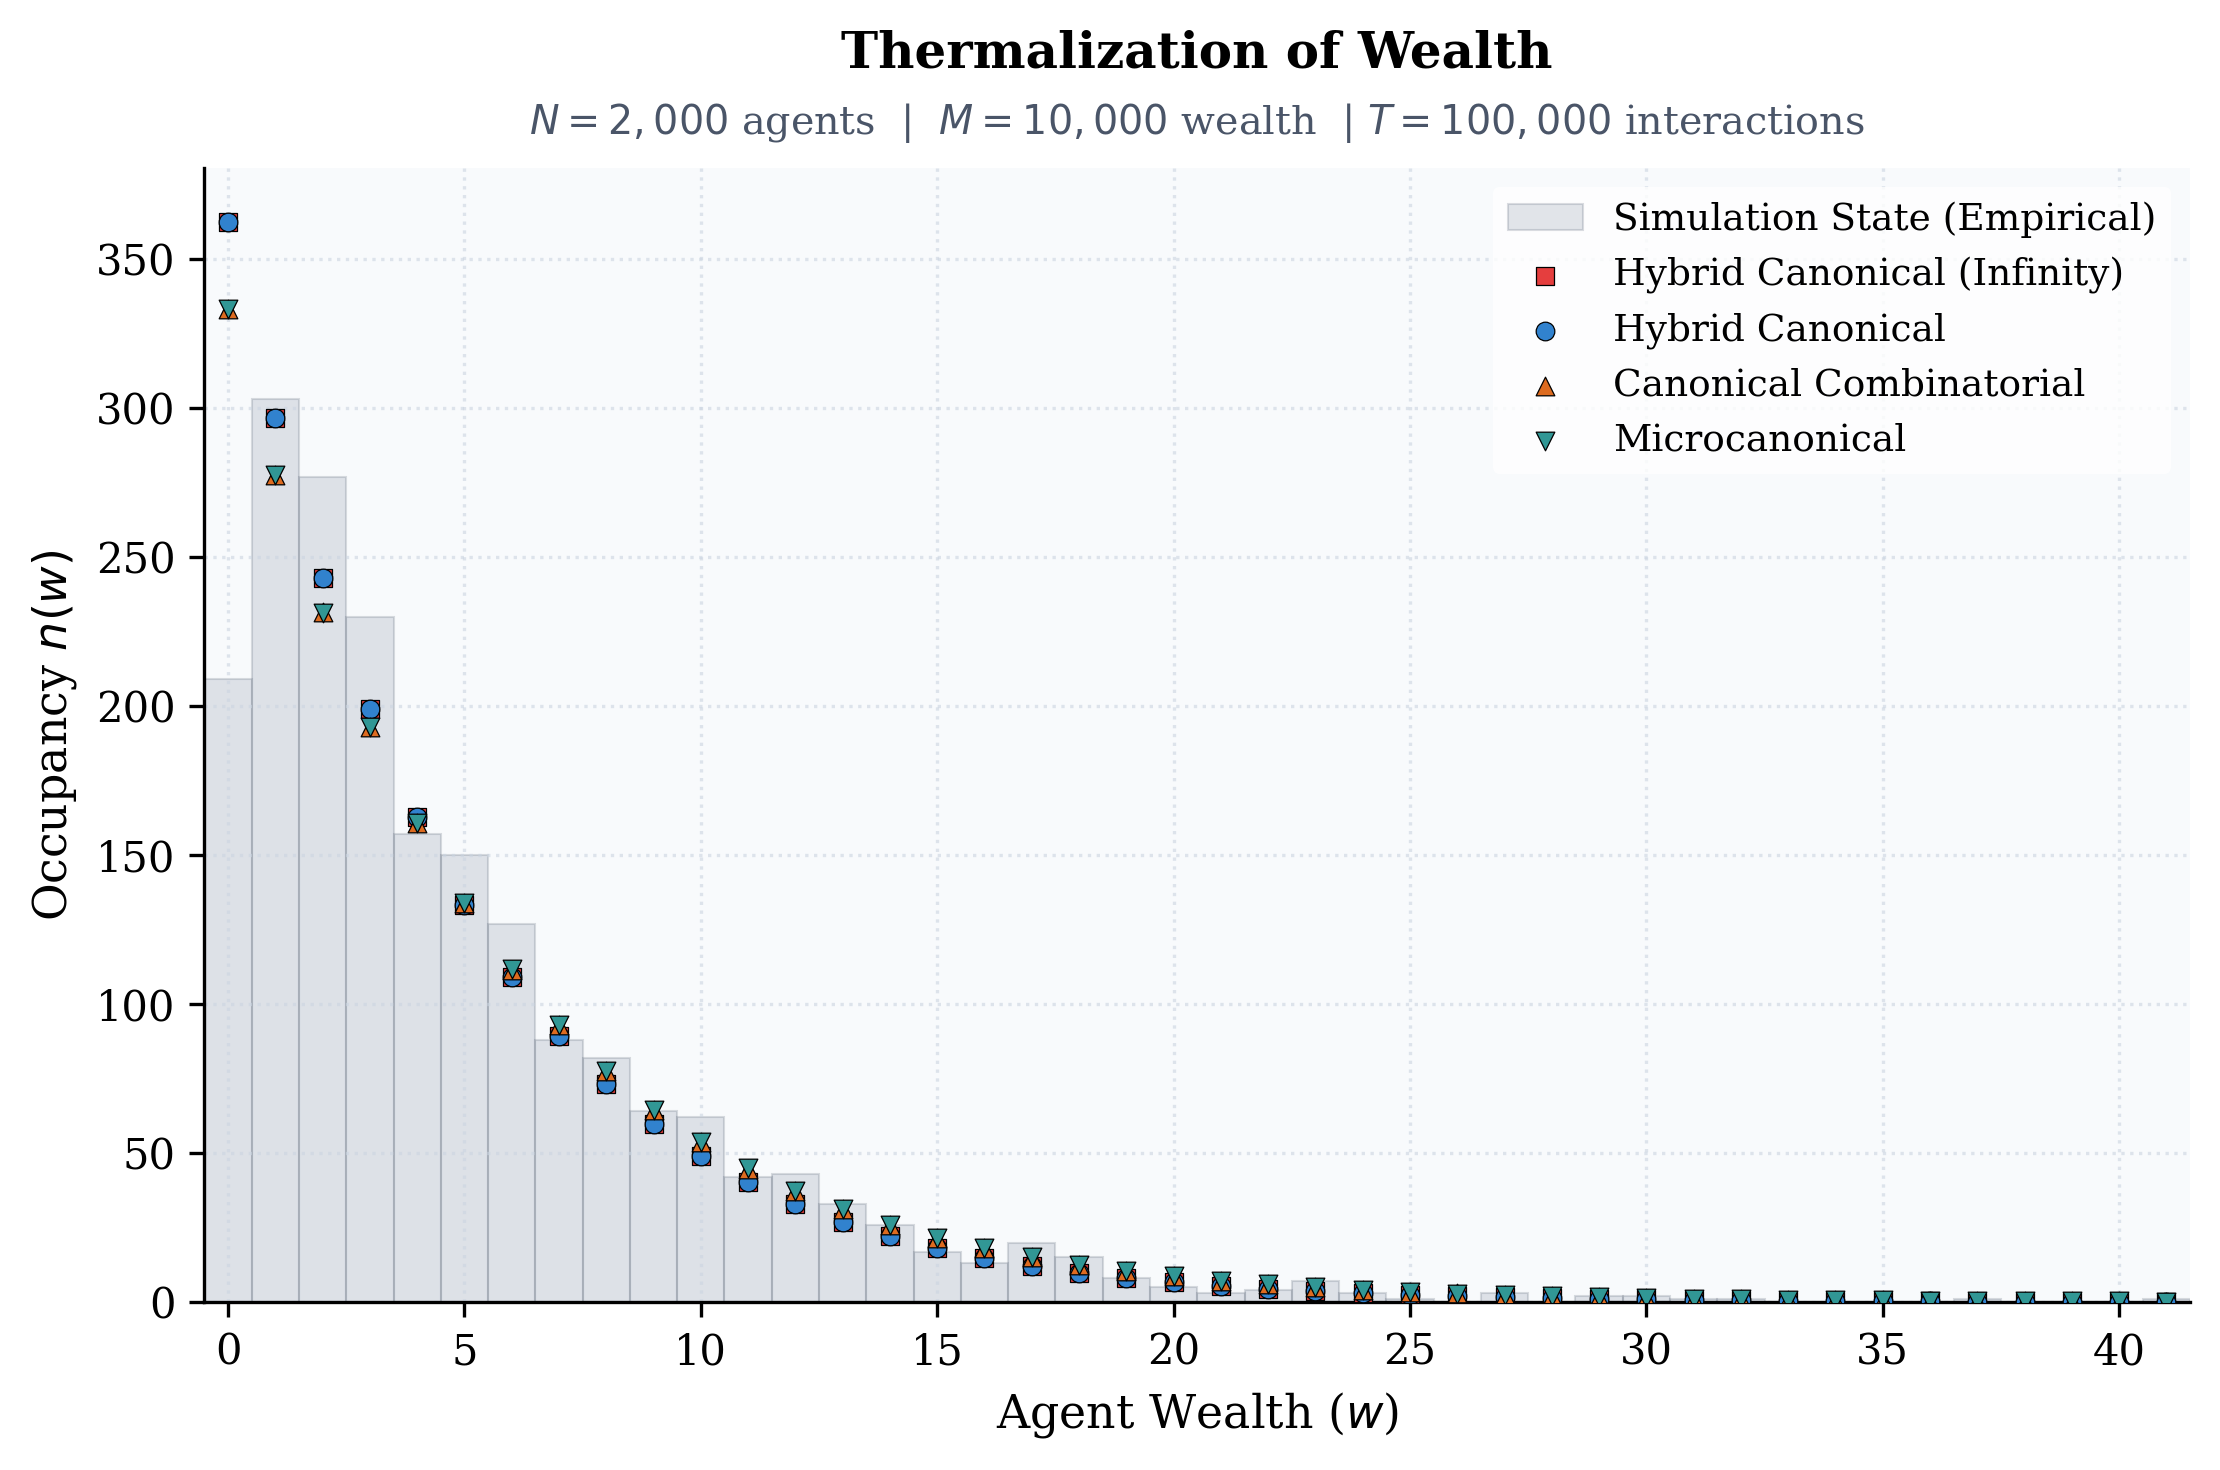

In [27]:
fig = plot_wealth_distribution(
    final_wealths=final_wealths,
    theory_dict=theory_curves, num_agents=num_agents, total_wealth=total_wealth, transactions=num_transactions,
    density=False, plot_title='Thermalization of Wealth'
)

Systematically observing the theoretical predictions overestimating the base level occupancy and underestimating the occupancies of the next few wealth levels. This suggests a mechanism at works which does not satisfy the assumptions. The truncated random split will be understood to introduce a bias away from the extreme splits in an interaction, i.e., an agent will be found less likely to have zero or all the pot money at each interaction than all other values in between.